# Biomedical Image Analysis Assignment

## Hybrid pipeline: VLM + Classical Image Processing + U-Net + Structured LLM Output

This notebook implements the required assignment pipeline:

1. **Task 1:** Data preparation, EDA, and direct multimodal LLM (VLM) description  
2. **Task 2:** Otsu segmentation, region features, and numbers-first LLM interpretation  
3. **Task 3:** Small PyTorch U-Net segmentation with Dice and IoU evaluation  
4. **Task 4:** Hybrid test pipeline producing structured JSON, narratives, and an aggregated CSV  
5. **Optional extension:** robustness test with a blurred image  

### Educational-use warning
This notebook is for coursework only. The models and outputs are **not clinically validated** and must not be used for diagnosis or patient care.

> Run the notebook from top to bottom. The code is intentionally kept simple and commented.

# 0. Setup

The notebook uses:

- NumPy and pandas
- Matplotlib
- Pillow
- scikit-image
- scikit-learn
- PyTorch
- Requests
- Ollama running locally

The next cell installs a package only if it is missing.

In [ ]:
import sys
import subprocess
import importlib.util

packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "PIL": "pillow",
    "skimage": "scikit-image",
    "sklearn": "scikit-learn",
    "torch": "torch",
    "requests": "requests",
    "tqdm": "tqdm"
}

missing = []

for module_name, package_name in packages.items():
    if importlib.util.find_spec(module_name) is None:
        missing.append(package_name)

if len(missing) > 0:
    print("Installing missing packages:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing)
else:
    print("All required Python packages are already installed.")

In [1]:
from pathlib import Path
import os
import io
import re
import json
import base64
import zipfile
import random
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import requests

from skimage.filters import threshold_otsu, gaussian
from skimage.morphology import (
    remove_small_objects,
    remove_small_holes,
    binary_opening,
    binary_closing,
    disk
)
from skimage.measure import label, regionprops_table

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch device:", DEVICE)

PyTorch device: cpu


# 1. Configuration

You can normally leave these settings unchanged.

The assignment specifies:

- Image size: **256 × 256**
- Vision model: **llama3.2-vision**
- Local Ollama server

For the numbers-first text step, this notebook tries `llama3.2:3b`.  
If that model is not installed, the code automatically falls back to the vision model for text-only prompting.

If needed, run these commands in a terminal:

```bash
ollama pull llama3.2-vision
ollama pull llama3.2:3b
```

In [3]:
IMAGE_SIZE = 256
BATCH_SIZE = 4
EPOCHS = 10
LEARNING_RATE = 1e-3

VISION_MODEL = "llama3.2-vision"
TEXT_MODEL = "llama3.2:3b"

OLLAMA_URL = "http://localhost:11434"

BASE_DIR = Path.cwd()
DATASET_ZIP = BASE_DIR / "nuclei_dataset.zip"
DATA_DIR = BASE_DIR / "nuclei_dataset"
PROCESSED_DIR = BASE_DIR / "processed_256"
OUTPUT_DIR = BASE_DIR / "outputs"

PROCESSED_IMAGE_DIR = PROCESSED_DIR / "images"
PROCESSED_MASK_DIR = PROCESSED_DIR / "masks"

OUTPUT_DIR.mkdir(exist_ok=True)

print("Working")

Working


# 2. Download and Extract the Dataset

The supplied GitHub repository provides the dataset as `nuclei_dataset.zip`.

The next cell:

1. Uses a local `nuclei_dataset.zip` if you already downloaded it.
2. Otherwise tries several equivalent GitHub download URLs.
3. Extracts the ZIP into `nuclei_dataset/`.

If automatic downloading is blocked, manually download the ZIP from:

`https://github.com/Nickolay-K/Assingnment-3-dataset`

Place `nuclei_dataset.zip` in the same folder as this notebook and rerun the cell.

In [5]:
DATASET_URLS = [
    "https://github.com/Nickolay-K/Assingnment-3-dataset/raw/refs/heads/main/nuclei_dataset.zip",
    "https://github.com/Nickolay-K/Assingnment-3-dataset/raw/main/nuclei_dataset.zip",
    "https://github.com/Nickolay-K/Assingnment-3-dataset/blob/main/nuclei_dataset.zip?raw=1",
    "https://raw.githubusercontent.com/Nickolay-K/Assingnment-3-dataset/main/nuclei_dataset.zip",
]

def looks_like_zip(path):
    if not path.exists():
        return False

    try:
        with zipfile.ZipFile(path, "r") as z:
            return len(z.namelist()) > 0
    except zipfile.BadZipFile:
        return False


if not looks_like_zip(DATASET_ZIP):
    print("Dataset ZIP not found locally. Trying to download it...")

    downloaded = False

    for url in DATASET_URLS:
        try:
            print("Trying:", url)

            response = requests.get(
                url,
                timeout=120,
                allow_redirects=True,
                headers={"User-Agent": "Mozilla/5.0"}
            )

            if response.status_code == 200 and len(response.content) > 1000:
                DATASET_ZIP.write_bytes(response.content)

                if looks_like_zip(DATASET_ZIP):
                    downloaded = True
                    print("Download successful.")
                    break

        except Exception as e:
            print("This URL did not work:", str(e)[:150])

    if not downloaded:
        raise RuntimeError(
            "Automatic download failed. Download nuclei_dataset.zip manually "
            "from the assignment GitHub repository, place it beside this notebook, "
            "and rerun this cell."
        )
else:
    print("Using existing dataset ZIP")


if not DATA_DIR.exists() or len(list(DATA_DIR.rglob("*"))) == 0:
    DATA_DIR.mkdir(exist_ok=True)

    with zipfile.ZipFile(DATASET_ZIP, "r") as z:
        z.extractall(DATA_DIR)

    print("Dataset extracted")
else:
    print("Dataset already extracted")

Using existing dataset ZIP
Dataset already extracted


# 3. Discover Images and Masks Automatically

The notebook detects:

- ordinary image files;
- masks in folders such as `masks`, `labels`, `gt`, or `ground_truth`;
- the common nuclei layout where one image has a sibling `masks/` folder containing multiple individual masks.

All individual masks for one image are combined into one binary ground-truth mask.

In [7]:
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"}

MASK_FOLDER_NAMES = {
    "mask", "masks", "label", "labels",
    "gt", "ground_truth", "groundtruth",
    "segmentation", "segmentations"
}

def is_image_file(path):
    return path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS


def path_looks_like_mask(path):
    parts = [part.lower() for part in path.parts]
    stem = path.stem.lower()

    if any(part in MASK_FOLDER_NAMES for part in parts):
        return True

    if "mask" in stem or stem.endswith("_gt") or stem.startswith("gt_"):
        return True

    return False


all_image_files = [
    p for p in DATA_DIR.rglob("*")
    if is_image_file(p) and "__MACOSX" not in p.parts
]

possible_masks = [p for p in all_image_files if path_looks_like_mask(p)]
possible_images = [p for p in all_image_files if not path_looks_like_mask(p)]

print("Total image-like files:", len(all_image_files))
print("Possible source images:", len(possible_images))
print("Possible mask files:", len(possible_masks))

Total image-like files: 340
Possible source images: 116
Possible mask files: 224


In [8]:
def find_masks_for_image(image_path, all_masks):
    found = []

    # Common nuclei layout:
    # sample_id/images/sample_id.png
    # sample_id/masks/mask1.png, mask2.png, ...
    if image_path.parent.name.lower() in {"image", "images"}:
        sample_folder = image_path.parent.parent

        for mask_folder_name in ["masks", "mask", "labels", "label", "gt", "ground_truth"]:
            mask_folder = sample_folder / mask_folder_name

            if mask_folder.exists():
                found = [
                    p for p in mask_folder.rglob("*")
                    if is_image_file(p)
                ]

                if len(found) > 0:
                    return sorted(found)

    # Parallel folders with the same filename
    same_stem = [
        p for p in all_masks
        if p.stem.lower() == image_path.stem.lower()
    ]

    if len(same_stem) > 0:
        return sorted(same_stem)

    # Files such as image_001_mask.png
    stem_matches = [
        p for p in all_masks
        if image_path.stem.lower() in p.stem.lower()
    ]

    return sorted(stem_matches)


records = []

for index, image_path in enumerate(sorted(possible_images)):
    masks = find_masks_for_image(image_path, possible_masks)

    if image_path.parent.name.lower() in {"image", "images"}:
        image_id = image_path.parent.parent.name
    else:
        image_id = image_path.stem

    image_id = f"{index:04d}_{image_id}"

    records.append({
        "image_id": image_id,
        "image_path": image_path,
        "mask_paths": masks
    })


print("Detected image records:", len(records))
print("Records with masks:", sum(len(r["mask_paths"]) > 0 for r in records))
print("Records without masks:", sum(len(r["mask_paths"]) == 0 for r in records))

if len(records) == 0:
    raise RuntimeError(
        "No images were detected. Inspect the extracted dataset folder "
        "and adjust the discovery rules if your copy uses an unusual format."
    )

Detected image records: 116
Records with masks: 112
Records without masks: 4


# 4. Preprocess Images to 256 × 256 Grayscale

This performs the required preprocessing:

- convert images to grayscale;
- resize to 256 × 256;
- combine individual object masks;
- resize masks with nearest-neighbour interpolation;
- save processed files into `processed_256/`.

In [10]:
def load_grayscale_image(path, size=IMAGE_SIZE):
    image = Image.open(path).convert("L")
    image = image.resize((size, size), Image.Resampling.BILINEAR)

    array = np.asarray(image, dtype=np.float32) / 255.0

    return array


def load_combined_mask(mask_paths, size=IMAGE_SIZE):
    combined = np.zeros((size, size), dtype=np.uint8)

    for path in mask_paths:
        mask = Image.open(path).convert("L")
        mask = mask.resize((size, size), Image.Resampling.NEAREST)

        mask_array = np.asarray(mask)
        combined[mask_array > 0] = 1

    return combined


PROCESSED_IMAGE_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_MASK_DIR.mkdir(parents=True, exist_ok=True)

processed_records = []

for record in records:
    image = load_grayscale_image(record["image_path"])

    image_uint8 = (image * 255).astype(np.uint8)
    image_save_path = PROCESSED_IMAGE_DIR / f'{record["image_id"]}.png'

    Image.fromarray(image_uint8).save(image_save_path)

    mask_save_path = None

    if len(record["mask_paths"]) > 0:
        mask = load_combined_mask(record["mask_paths"])
        mask_save_path = PROCESSED_MASK_DIR / f'{record["image_id"]}.png'

        Image.fromarray((mask * 255).astype(np.uint8)).save(mask_save_path)

    processed_records.append({
        "image_id": record["image_id"],
        "image_path": image_save_path,
        "mask_path": mask_save_path
    })


print("Processed records:", len(processed_records))
print("Processed images saved")
print("Processed masks saved")

Processed records: 116
Processed images saved
Processed masks saved


# 5. Create Train, Validation, and Test Splits

Only images with ground-truth masks can train/evaluate the U-Net.

- **Train:** model fitting
- **Validation:** Dice/IoU and visual comparisons
- **Test:** unseen data for the final pipeline

Any originally unlabeled images are kept separately.

In [12]:
labelled_records = [
    r for r in processed_records
    if r["mask_path"] is not None
]

unlabelled_records = [
    r for r in processed_records
    if r["mask_path"] is None
]

if len(labelled_records) < 3:
    raise RuntimeError(
        "At least 3 labelled images are needed for train/validation/test splitting."
    )

if len(labelled_records) >= 7:
    train_records, temp_records = train_test_split(
        labelled_records,
        test_size=0.30,
        random_state=SEED
    )

    val_records, test_records = train_test_split(
        temp_records,
        test_size=0.50,
        random_state=SEED
    )
else:
    shuffled = labelled_records.copy()
    random.Random(SEED).shuffle(shuffled)

    test_records = [shuffled[-1]]
    val_records = [shuffled[-2]]
    train_records = shuffled[:-2]


print("Train images:", len(train_records))
print("Validation images:", len(val_records))
print("Held-out test images:", len(test_records))
print("Additional unlabeled images:", len(unlabelled_records))

Train images: 78
Validation images: 17
Held-out test images: 17
Additional unlabeled images: 4


# Task 1 — Data Preparation and EDA

## 6. Show a Sample of Images

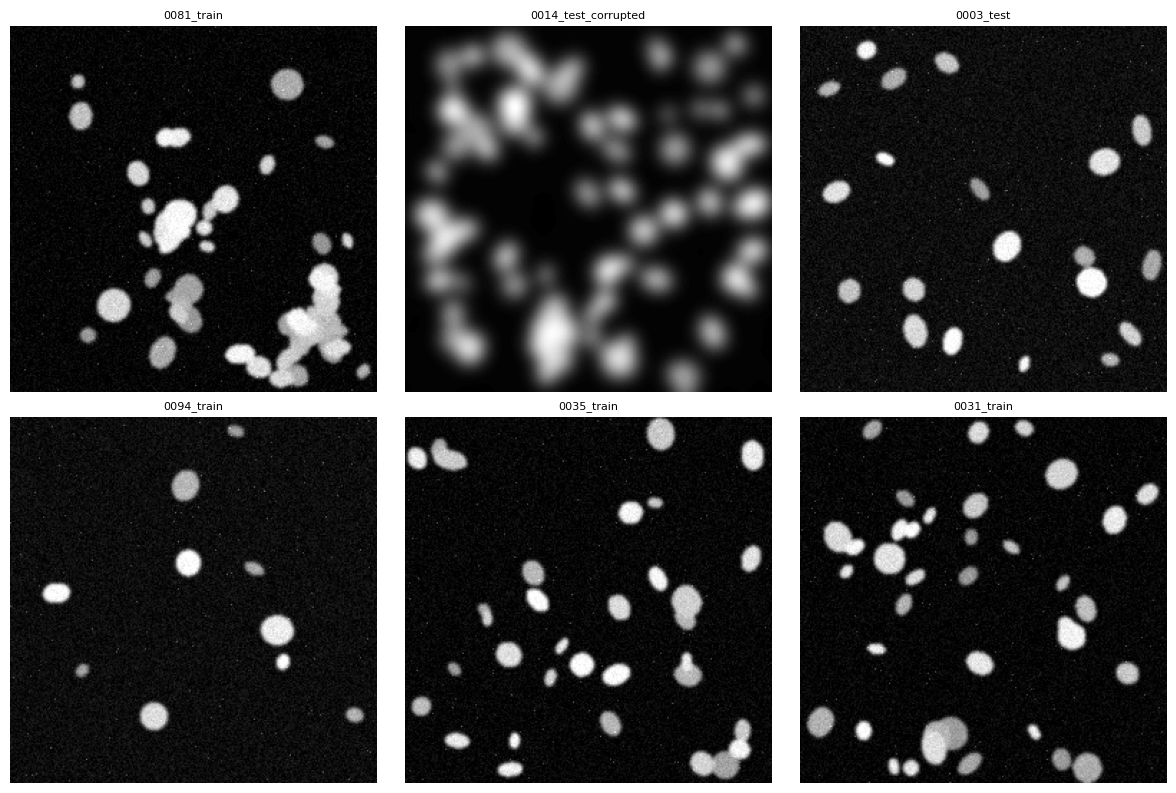

In [14]:
sample_count = min(6, len(processed_records))
sample_records = random.sample(processed_records, sample_count)

columns = 3
rows = int(np.ceil(sample_count / columns))

plt.figure(figsize=(12, 4 * rows))

for i, record in enumerate(sample_records):
    image = load_grayscale_image(record["image_path"])

    plt.subplot(rows, columns, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(record["image_id"], fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

## 7. Intensity Histogram

This supports discussion of image brightness, contrast, and whether thresholding is likely to work.

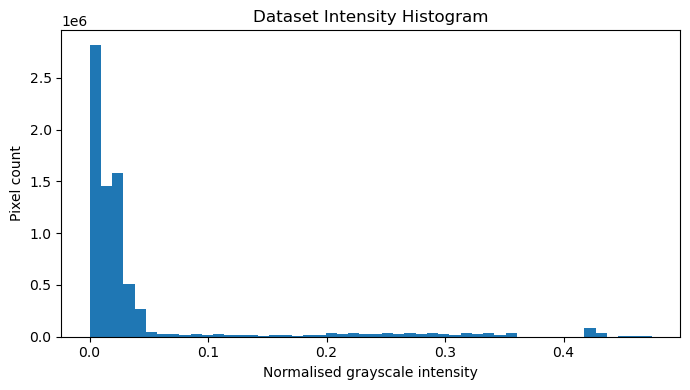

Mean intensity: 0.043
Standard deviation: 0.0871
Minimum: 0.0
Maximum: 0.4745


In [16]:
all_pixels = []

for record in processed_records:
    image = load_grayscale_image(record["image_path"])
    all_pixels.append(image.ravel())

all_pixels = np.concatenate(all_pixels)

plt.figure(figsize=(7, 4))
plt.hist(all_pixels, bins=50)
plt.xlabel("Normalised grayscale intensity")
plt.ylabel("Pixel count")
plt.title("Dataset Intensity Histogram")
plt.tight_layout()
plt.show()

print("Mean intensity:", round(float(all_pixels.mean()), 4))
print("Standard deviation:", round(float(all_pixels.std()), 4))
print("Minimum:", round(float(all_pixels.min()), 4))
print("Maximum:", round(float(all_pixels.max()), 4))

# Task 1 — Direct Multimodal LLM Description

## 8. Check Ollama

If a model is missing, run in a terminal:

```bash
ollama pull llama3.2-vision
ollama pull llama3.2:3b
```

In [18]:
def get_ollama_models():
    try:
        response = requests.get(
            OLLAMA_URL + "/api/tags",
            timeout=10
        )
        response.raise_for_status()

        data = response.json()
        model_names = []

        for item in data.get("models", []):
            name = item.get("name", "")

            if name:
                model_names.append(name)

        return model_names

    except Exception as e:
        print("Could not connect to Ollama.")
        print("Make sure Ollama is running.")
        print("Details:", str(e))
        return []


installed_models = get_ollama_models()

print("Installed Ollama models:")
for model_name in installed_models:
    print(" -", model_name)


def model_is_installed(requested_name, model_list):
    requested_base = requested_name.split(":")[0]

    for model_name in model_list:
        if model_name == requested_name:
            return True

        if model_name.split(":")[0] == requested_base:
            return True

    return False


if not model_is_installed(VISION_MODEL, installed_models):
    print("\nWARNING: Vision model not found.")
    print("Run: ollama pull", VISION_MODEL)


if not model_is_installed(TEXT_MODEL, installed_models):
    print("\nText model was not found.")
    print("The notebook will use the vision model for text-only calls.")
    TEXT_MODEL = VISION_MODEL

print("\nVision model:", VISION_MODEL)
print("Text model:", TEXT_MODEL)

Installed Ollama models:
 - llama3.2-vision:latest
 - llama3.2:latest

Vision model: llama3.2-vision
Text model: llama3.2:3b


## 9. Ollama Helper Functions

Image data is sent to the local Ollama server as base64.

For structured steps, `format="json"` is requested.

In [25]:
def image_to_base64(image_path):
    with open(image_path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")


def call_ollama(
    prompt,
    model,
    image_path=None,
    temperature=0.2,
    json_mode=False
):
    payload = {
        "model": model,
        "prompt": prompt,
        "stream": False,
        "options": {
            "temperature": temperature
        }
    }

    if image_path is not None:
        payload["images"] = [image_to_base64(image_path)]

    if json_mode:
        payload["format"] = "json"

    try:
        response = requests.post(
            OLLAMA_URL + "/api/generate",
            json=payload,
            timeout=600
        )

        response.raise_for_status()

        return response.json().get("response", "").strip()

    except Exception as e:
        print("Ollama call failed:", str(e))
        return ""


def safe_json(text):
    if text is None or text.strip() == "":
        return None

    cleaned = text.strip()
    cleaned = cleaned.replace("```json", "").replace("```", "").strip()

    try:
        return json.loads(cleaned)
    except Exception:
        pass

    start = cleaned.find("{")
    end = cleaned.rfind("}")

    if start != -1 and end != -1 and end > start:
        try:
            return json.loads(cleaned[start:end + 1])
        except Exception:
            return None

    return None

## 10. Choose a Representative Image

The middle processed image is used initially. You can later replace it with a more representative example if needed.

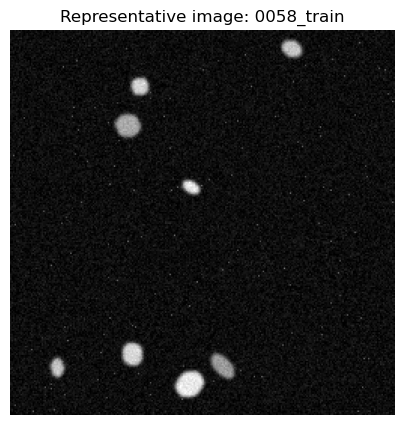

In [27]:
representative_record = processed_records[len(processed_records) // 2]
representative_path = representative_record["image_path"]

representative_image = load_grayscale_image(representative_path)

plt.figure(figsize=(5, 5))
plt.imshow(representative_image, cmap="gray")
plt.title("Representative image: " + representative_record["image_id"])
plt.axis("off")
plt.show()

## 11. Naive VLM Prompt

This intentionally weak prompt provides the baseline comparison.

In [29]:
NAIVE_VLM_PROMPT = """
Describe this medical image.
"""

naive_vlm_output = call_ollama(
    prompt=NAIVE_VLM_PROMPT,
    model=VISION_MODEL,
    image_path=representative_path,
    temperature=0.7,
    json_mode=False
)

print("NAIVE PROMPT:")
print(NAIVE_VLM_PROMPT)

print("\nNAIVE OUTPUT:")
print(naive_vlm_output)

Ollama call failed: 500 Server Error: Internal Server Error for url: http://localhost:11434/api/generate
NAIVE PROMPT:

Describe this medical image.


NAIVE OUTPUT:



## 12. Optimised Structured VLM Prompt

This prompt reduces hallucination by:

- requiring description rather than diagnosis;
- explicitly allowing `"uncertain"`;
- restricting output to a small JSON schema;
- asking only for visually supported information.

**Copy this exact prompt into the report.**

In [35]:
OPTIMISED_VLM_PROMPT = """
You are analysing a biomedical image for an educational image-analysis assignment.

Your task is DESCRIPTIVE, not diagnostic.

Rules:
1. Describe only visual information that is reasonably supported by the image.
2. Do not diagnose a disease, condition, tumour, infection, or patient status.
3. Do not invent clinical history, stain type, acquisition details, or anatomy.
4. If a requested field cannot be determined from the image, write "uncertain".
5. Keep notable_features short and factual.
6. Return JSON only. Do not include markdown or additional commentary.

Return exactly this structure:
{
  "modality": "string or uncertain",
  "tissue_type": "string or uncertain",
  "notable_features": ["short visible feature", "short visible feature"],
  "image_quality": "good, moderate, poor, or uncertain"
}
"""

optimised_vlm_output = call_ollama(
    prompt=OPTIMISED_VLM_PROMPT,
    model=VISION_MODEL,
    image_path=representative_path,
    temperature=0.2,
    json_mode=True
)

optimised_vlm_json = safe_json(optimised_vlm_output)

print("OPTIMISED PROMPT:")
print(OPTIMISED_VLM_PROMPT)

print("\nOPTIMISED OUTPUT:")
print(optimised_vlm_output)

print("\nPARSED JSON:")
if optimised_vlm_json is not None:
    print(json.dumps(optimised_vlm_json, indent=2))
else:
    print("Could not parse JSON.")

Ollama call failed: 500 Server Error: Internal Server Error for url: http://localhost:11434/api/generate
OPTIMISED PROMPT:

You are analysing a biomedical image for an educational image-analysis assignment.

Your task is DESCRIPTIVE, not diagnostic.

Rules:
1. Describe only visual information that is reasonably supported by the image.
2. Do not diagnose a disease, condition, tumour, infection, or patient status.
3. Do not invent clinical history, stain type, acquisition details, or anatomy.
4. If a requested field cannot be determined from the image, write "uncertain".
5. Keep notable_features short and factual.
6. Return JSON only. Do not include markdown or additional commentary.

Return exactly this structure:
{
  "modality": "string or uncertain",
  "tissue_type": "string or uncertain",
  "notable_features": ["short visible feature", "short visible feature"],
  "image_quality": "good, moderate, poor, or uncertain"
}


OPTIMISED OUTPUT:


PARSED JSON:
Could not parse JSON.


## 13. Repeated VLM Runs

The same image and prompt are run three times at a higher temperature to demonstrate possible non-determinism.

In [40]:
repeated_outputs = []

for run_number in range(3):
    output = call_ollama(
        prompt=OPTIMISED_VLM_PROMPT,
        model=VISION_MODEL,
        image_path=representative_path,
        temperature=0.7,
        json_mode=True
    )

    repeated_outputs.append(output)

    print("\nRUN", run_number + 1)
    print(output)


unique_outputs = len(set(repeated_outputs))

print("\nUnique outputs out of 3 runs:", unique_outputs)

if unique_outputs > 1:
    print("The repeated runs were not identical.")
else:
    print(
        "These three runs happened to be identical. "
        "Rerun the cell or increase temperature slightly if needed."
    )

Ollama call failed: 500 Server Error: Internal Server Error for url: http://localhost:11434/api/generate

RUN 1

Ollama call failed: 500 Server Error: Internal Server Error for url: http://localhost:11434/api/generate

RUN 2

Ollama call failed: 500 Server Error: Internal Server Error for url: http://localhost:11434/api/generate

RUN 3


Unique outputs out of 3 runs: 1
These three runs happened to be identical. Rerun the cell or increase temperature slightly if needed.


# Task 2 — Classical Image Processing

## 14. Otsu Thresholding and Morphological Cleanup

Pipeline:

1. Otsu threshold
2. Foreground polarity check
3. Remove small objects
4. Remove small holes
5. Opening
6. Closing
7. Connected components

In [42]:
def otsu_segment(image):
    threshold = threshold_otsu(image)

    mask = image > threshold

    if mask.mean() > 0.50:
        mask = image < threshold

    mask = remove_small_objects(mask, min_size=20)
    mask = remove_small_holes(mask, area_threshold=20)

    mask = binary_opening(mask, disk(1))
    mask = binary_closing(mask, disk(1))

    return mask.astype(np.uint8), threshold

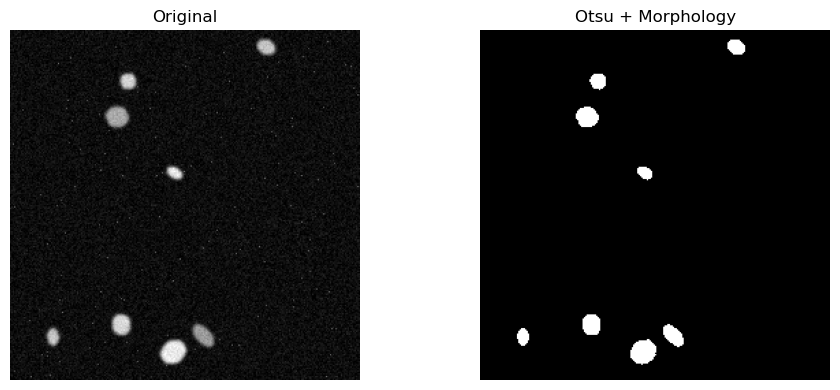

Otsu threshold: 0.1289
Foreground fraction: 0.0183


In [43]:
otsu_mask, otsu_threshold = otsu_segment(representative_image)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(representative_image, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(otsu_mask, cmap="gray")
plt.title("Otsu + Morphology")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Otsu threshold:", round(float(otsu_threshold), 4))
print("Foreground fraction:", round(float(otsu_mask.mean()), 4))

## 15. Extract Region Features with `regionprops_table`

Required features include area, eccentricity, solidity, and mean intensity.

The notebook also records perimeter and equivalent diameter.

In [45]:
REGION_PROPERTIES = [
    "label",
    "area",
    "eccentricity",
    "solidity",
    "perimeter",
    "equivalent_diameter_area",
    "mean_intensity"
]

def extract_region_features(image, binary_mask):
    labelled_mask = label(binary_mask)

    table = regionprops_table(
        labelled_mask,
        intensity_image=image,
        properties=REGION_PROPERTIES
    )

    dataframe = pd.DataFrame(table)

    return dataframe, labelled_mask


representative_features, representative_labels = extract_region_features(
    representative_image,
    otsu_mask
)

print("Number of detected objects:", len(representative_features))
display(representative_features.head(10))

representative_features.to_csv(
    OUTPUT_DIR / "representative_otsu_region_features.csv",
    index=False
)

Number of detected objects: 8


,label,area,eccentricity,solidity,perimeter,equivalent_diameter_area,mean_intensity
0,1,117.0,0.635987,1.000000,36.970563,12.205287,0.237640
1,2,111.0,0.238678,0.948718,36.970563,11.888212,0.250062
2,3,198.0,0.426725,0.956522,50.041631,15.877702,0.212498
3,4,81.0,0.726698,0.964286,31.556349,10.155413,0.263713
4,5,172.0,0.510144,0.988506,45.556349,14.798554,0.261035
5,6,164.0,0.832130,0.953488,48.284271,14.450304,0.194668
6,7,88.0,0.731277,0.956522,32.970563,10.585135,0.230214
7,8,267.0,0.494690,0.953571,59.941125,18.437868,0.285981


## 16. Convert the Feature Table to a Numbers-First Summary

Only numerical measurements are included. The LLM will not receive the image.

In [53]:
def summarise_feature_table(feature_table, image_shape):
    image_area = image_shape[0] * image_shape[1]
    n_objects = len(feature_table)

    if n_objects == 0:
        return {
            "n_objects": 0,
            "mean_area": 0.0,
            "median_area": 0.0,
            "total_object_area": 0.0,
            "foreground_fraction": 0.0,
            "mean_eccentricity": 0.0,
            "mean_solidity": 0.0,
            "mean_intensity": 0.0
        }

    return {
        "n_objects": int(n_objects),
        "mean_area": float(feature_table["area"].mean()),
        "median_area": float(feature_table["area"].median()),
        "total_object_area": float(feature_table["area"].sum()),
        "foreground_fraction": float(feature_table["area"].sum() / image_area),
        "mean_eccentricity": float(feature_table["eccentricity"].mean()),
        "mean_solidity": float(feature_table["solidity"].mean()),
        "mean_intensity": float(feature_table["mean_intensity"].mean())
    }


representative_numeric_summary = summarise_feature_table(
    representative_features,
    representative_image.shape
)

print(json.dumps(representative_numeric_summary, indent=2))

{
  "n_objects": 8,
  "mean_area": 149.75,
  "median_area": 140.5,
  "total_object_area": 1198.0,
  "foreground_fraction": 0.018280029296875,
  "mean_eccentricity": 0.5745412327122719,
  "mean_solidity": 0.9652015861319276,
  "mean_intensity": 0.24197631888091564
}


## 17. Numbers-First LLM Prompt

Required JSON fields:

- `n_objects`
- `density_class`
- `shape_regularity`
- `quality_flag`

**Copy this exact prompt into the report.**

In [56]:
NUMBERS_FIRST_PROMPT_TEMPLATE = """
You are interpreting quantitative measurements from a biomedical image-analysis pipeline.

IMPORTANT:
- You cannot see the image.
- You only have the measured numbers below.
- Do not diagnose disease or make clinical claims.
- Do not invent visual details that are not supported by the numbers.
- If the measurements are insufficient, use "uncertain".

Measured values:
{numbers}

First write one short descriptive paragraph based only on the measurements.

Then provide a JSON object using exactly these fields:
{{
  "n_objects": integer,
  "density_class": "low, moderate, high, or uncertain",
  "shape_regularity": "regular, mixed, irregular, or uncertain",
  "quality_flag": "ok, review, or uncertain"
}}

Keep the paragraph descriptive and non-diagnostic.
"""

numbers_text = json.dumps(
    representative_numeric_summary,
    indent=2
)

numbers_first_prompt = NUMBERS_FIRST_PROMPT_TEMPLATE.format(
    numbers=numbers_text
)

numbers_first_output = call_ollama(
    prompt=numbers_first_prompt,
    model=TEXT_MODEL,
    image_path=None,
    temperature=0.2,
    json_mode=False
)

print("NUMBERS-FIRST PROMPT:")
print(numbers_first_prompt)

print("\nNUMBERS-FIRST OUTPUT:")
print(numbers_first_output)

Ollama call failed: 404 Client Error: Not Found for url: http://localhost:11434/api/generate
NUMBERS-FIRST PROMPT:

You are interpreting quantitative measurements from a biomedical image-analysis pipeline.

IMPORTANT:
- You cannot see the image.
- You only have the measured numbers below.
- Do not diagnose disease or make clinical claims.
- Do not invent visual details that are not supported by the numbers.
- If the measurements are insufficient, use "uncertain".

Measured values:
{
  "n_objects": 8,
  "mean_area": 149.75,
  "median_area": 140.5,
  "total_object_area": 1198.0,
  "foreground_fraction": 0.018280029296875,
  "mean_eccentricity": 0.5745412327122719,
  "mean_solidity": 0.9652015861319276,
  "mean_intensity": 0.24197631888091564
}

First write one short descriptive paragraph based only on the measurements.

Then provide a JSON object using exactly these fields:
{
  "n_objects": integer,
  "density_class": "low, moderate, high, or uncertain",
  "shape_regularity": "regular, m

## 18. Direct VLM vs Numbers-First Comparison

Use this table to support the discussion of usefulness, trustworthiness, and auditability.

In [58]:
comparison_table = pd.DataFrame([
    {
        "Method": "Direct VLM",
        "Input to LLM": "Image",
        "Output": optimised_vlm_output
    },
    {
        "Method": "Numbers-first",
        "Input to LLM": "Measured region features only",
        "Output": numbers_first_output
    }
])

display(comparison_table)

,Method,Input to LLM,Output
0,Direct VLM,Image,
1,Numbers-first,Measured region features only,


# Task 3 — U-Net Segmentation

## 19. PyTorch Dataset Class

In [60]:
class NucleiDataset(Dataset):
    def __init__(self, records):
        self.records = records

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        record = self.records[index]

        image = load_grayscale_image(record["image_path"])
        mask = load_grayscale_image(record["mask_path"])

        mask = (mask > 0.5).astype(np.float32)

        image_tensor = torch.tensor(
            image,
            dtype=torch.float32
        ).unsqueeze(0)

        mask_tensor = torch.tensor(
            mask,
            dtype=torch.float32
        ).unsqueeze(0)

        return image_tensor, mask_tensor, record["image_id"]

In [61]:
train_dataset = NucleiDataset(train_records)
val_dataset = NucleiDataset(val_records)
test_dataset = NucleiDataset(test_records)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Training batches: 20
Validation batches: 5


## 20. Small U-Net

A compact two-level U-Net is used so that training remains practical on a laptop.

In [63]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class SmallUNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = DoubleConv(1, 16)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(16, 32)
        self.pool2 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(32, 64)

        self.up2 = nn.ConvTranspose2d(
            64, 32,
            kernel_size=2,
            stride=2
        )
        self.dec2 = DoubleConv(64, 32)

        self.up1 = nn.ConvTranspose2d(
            32, 16,
            kernel_size=2,
            stride=2
        )
        self.dec1 = DoubleConv(32, 16)

        self.output = nn.Conv2d(
            16, 1,
            kernel_size=1
        )

    def forward(self, x):
        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        b = self.bottleneck(p2)

        u2 = self.up2(b)
        d2 = torch.cat([u2, e2], dim=1)
        d2 = self.dec2(d2)

        u1 = self.up1(d2)
        d1 = torch.cat([u1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.output(d1)


model = SmallUNet().to(DEVICE)

print(model)

SmallUNet(
  (enc1): DoubleConv(
    (block): Sequential(
      (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): DoubleConv(
    (block): Sequential(
      (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bottleneck): DoubleConv(
    (block): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )

## 21. Dice Loss, Dice Score, and IoU

Scores range from 0 to 1. Higher values mean better overlap.

In [65]:
def dice_loss(logits, targets, smooth=1e-6):
    probabilities = torch.sigmoid(logits)

    intersection = (probabilities * targets).sum(dim=(1, 2, 3))
    denominator = probabilities.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))

    dice = (2.0 * intersection + smooth) / (denominator + smooth)

    return 1.0 - dice.mean()


def bce_dice_loss(logits, targets):
    bce = nn.functional.binary_cross_entropy_with_logits(
        logits,
        targets
    )

    dice = dice_loss(logits, targets)

    return bce + dice


def dice_score_binary(predictions, targets, smooth=1e-6):
    predictions = predictions.astype(np.uint8)
    targets = targets.astype(np.uint8)

    intersection = np.logical_and(predictions, targets).sum()
    denominator = predictions.sum() + targets.sum()

    return float(
        (2.0 * intersection + smooth) /
        (denominator + smooth)
    )


def iou_score_binary(predictions, targets, smooth=1e-6):
    predictions = predictions.astype(np.uint8)
    targets = targets.astype(np.uint8)

    intersection = np.logical_and(predictions, targets).sum()
    union = np.logical_or(predictions, targets).sum()

    return float(
        (intersection + smooth) /
        (union + smooth)
    )

## 22. Training and Evaluation Functions

The main experiment uses **BCE + Dice loss** and 10 epochs.

In [67]:
def evaluate_model(model, loader):
    model.eval()

    dice_scores = []
    iou_scores = []

    with torch.no_grad():
        for images, masks, image_ids in loader:
            images = images.to(DEVICE)
            masks = masks.to(DEVICE)

            logits = model(images)
            probabilities = torch.sigmoid(logits)
            predictions = (probabilities > 0.5).float()

            for i in range(images.size(0)):
                prediction_np = predictions[i, 0].cpu().numpy()
                mask_np = masks[i, 0].cpu().numpy()

                dice_scores.append(
                    dice_score_binary(prediction_np, mask_np)
                )

                iou_scores.append(
                    iou_score_binary(prediction_np, mask_np)
                )

    return float(np.mean(dice_scores)), float(np.mean(iou_scores))


def train_unet(model, train_loader, val_loader, epochs):
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )

    history = {
        "train_loss": [],
        "val_dice": [],
        "val_iou": []
    }

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for images, masks, image_ids in train_loader:
            images = images.to(DEVICE)
            masks = masks.to(DEVICE)

            optimizer.zero_grad()

            logits = model(images)
            loss = bce_dice_loss(logits, masks)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        mean_train_loss = running_loss / max(len(train_loader), 1)

        val_dice, val_iou = evaluate_model(
            model,
            val_loader
        )

        history["train_loss"].append(mean_train_loss)
        history["val_dice"].append(val_dice)
        history["val_iou"].append(val_iou)

        print(
            f"Epoch {epoch + 1:02d}/{epochs} | "
            f"Loss: {mean_train_loss:.4f} | "
            f"Val Dice: {val_dice:.4f} | "
            f"Val IoU: {val_iou:.4f}"
        )

    return history

## 23. Train the U-Net

In [69]:
model = SmallUNet().to(DEVICE)

history = train_unet(
    model,
    train_loader,
    val_loader,
    EPOCHS
)

torch.save(
    model.state_dict(),
    OUTPUT_DIR / "small_unet_bce_dice.pth"
)

print("Model saved to:", OUTPUT_DIR / "small_unet_bce_dice.pth")

Epoch 01/10 | Loss: 0.9088 | Val Dice: 0.9259 | Val IoU: 0.8732
Epoch 02/10 | Loss: 0.4566 | Val Dice: 0.9259 | Val IoU: 0.8732
Epoch 03/10 | Loss: 0.4057 | Val Dice: 0.9259 | Val IoU: 0.8732
Epoch 04/10 | Loss: 0.4169 | Val Dice: 0.9259 | Val IoU: 0.8732
Epoch 05/10 | Loss: 0.4386 | Val Dice: 0.9259 | Val IoU: 0.8732
Epoch 06/10 | Loss: 0.4142 | Val Dice: 0.9259 | Val IoU: 0.8732
Epoch 07/10 | Loss: 0.4171 | Val Dice: 0.9259 | Val IoU: 0.8732
Epoch 08/10 | Loss: 0.4017 | Val Dice: 0.9273 | Val IoU: 0.8756
Epoch 09/10 | Loss: 0.3910 | Val Dice: 0.9293 | Val IoU: 0.8788
Epoch 10/10 | Loss: 0.4108 | Val Dice: 0.9309 | Val IoU: 0.8796
Model saved to: C:\Users\HASNAIN\FYPs-2026-2\aveee\outputs\small_unet_bce_dice.pth


## 24. Loss Curve

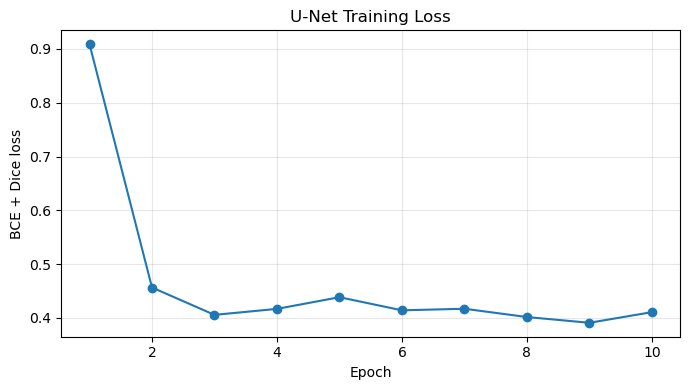

In [71]:
plt.figure(figsize=(7, 4))
plt.plot(
    range(1, EPOCHS + 1),
    history["train_loss"],
    marker="o"
)
plt.xlabel("Epoch")
plt.ylabel("BCE + Dice loss")
plt.title("U-Net Training Loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 25. Validation Dice and IoU Curves

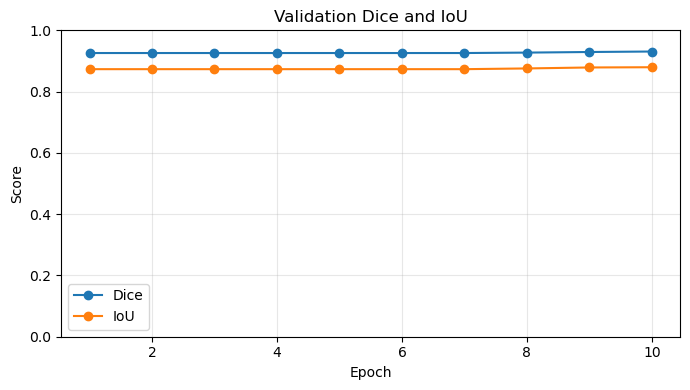

In [73]:
plt.figure(figsize=(7, 4))
plt.plot(
    range(1, EPOCHS + 1),
    history["val_dice"],
    marker="o",
    label="Dice"
)
plt.plot(
    range(1, EPOCHS + 1),
    history["val_iou"],
    marker="o",
    label="IoU"
)
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation Dice and IoU")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 26. Final Validation Dice and IoU

In [75]:
unet_val_dice, unet_val_iou = evaluate_model(
    model,
    val_loader
)

print("Mean validation Dice:", round(unet_val_dice, 4))
print("Mean validation IoU:", round(unet_val_iou, 4))

Mean validation Dice: 0.9309
Mean validation IoU: 0.8796


## 27. Input, Ground Truth, and U-Net Prediction

The assignment requires at least three validation examples.

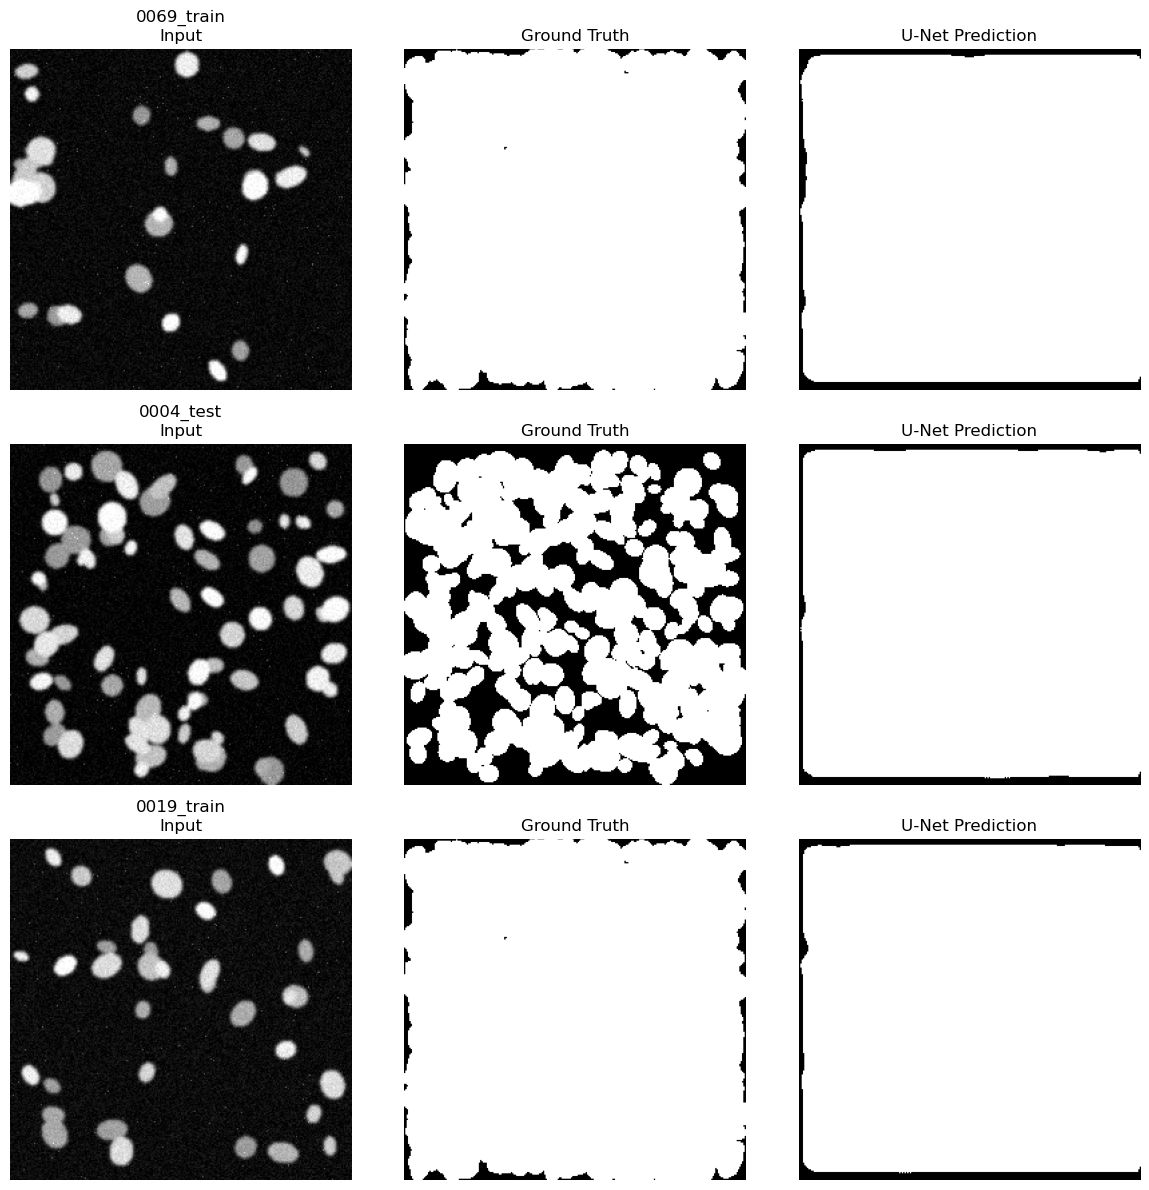

In [77]:
def predict_mask(model, image_array):
    model.eval()

    tensor = torch.tensor(
        image_array,
        dtype=torch.float32
    ).unsqueeze(0).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model(tensor)
        probability = torch.sigmoid(logits)[0, 0].cpu().numpy()

    prediction = (probability > 0.5).astype(np.uint8)

    return prediction, probability


number_to_show = min(3, len(val_records))

plt.figure(figsize=(12, 4 * number_to_show))

for row in range(number_to_show):
    record = val_records[row]

    image = load_grayscale_image(record["image_path"])
    ground_truth = load_grayscale_image(record["mask_path"]) > 0.5
    prediction, probability = predict_mask(model, image)

    plt.subplot(number_to_show, 3, row * 3 + 1)
    plt.imshow(image, cmap="gray")
    plt.title(record["image_id"] + "\nInput")
    plt.axis("off")

    plt.subplot(number_to_show, 3, row * 3 + 2)
    plt.imshow(ground_truth, cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(number_to_show, 3, row * 3 + 3)
    plt.imshow(prediction, cmap="gray")
    plt.title("U-Net Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Task 3 — Compare U-Net Against Otsu

## 28. Otsu and U-Net Metrics on the Same Validation Set

In [79]:
comparison_rows = []

for record in val_records:
    image = load_grayscale_image(record["image_path"])

    ground_truth = (
        load_grayscale_image(record["mask_path"]) > 0.5
    ).astype(np.uint8)

    otsu_prediction, threshold = otsu_segment(image)

    otsu_dice = dice_score_binary(
        otsu_prediction,
        ground_truth
    )

    otsu_iou = iou_score_binary(
        otsu_prediction,
        ground_truth
    )

    unet_prediction, probability = predict_mask(
        model,
        image
    )

    unet_dice = dice_score_binary(
        unet_prediction,
        ground_truth
    )

    unet_iou = iou_score_binary(
        unet_prediction,
        ground_truth
    )

    comparison_rows.append({
        "image_id": record["image_id"],
        "otsu_dice": otsu_dice,
        "otsu_iou": otsu_iou,
        "unet_dice": unet_dice,
        "unet_iou": unet_iou,
        "dice_difference_unet_minus_otsu": unet_dice - otsu_dice
    })


per_image_comparison = pd.DataFrame(comparison_rows)

display(per_image_comparison)

per_image_comparison.to_csv(
    OUTPUT_DIR / "per_image_otsu_vs_unet.csv",
    index=False
)

,image_id,otsu_dice,otsu_iou,unet_dice,unet_iou,dice_difference_unet_minus_otsu
0,0069_train,0.143418,0.077248,0.977560,0.956104,0.834142
1,0004_test,0.503702,0.336632,0.798240,0.664226,0.294538
2,0019_train,0.193023,0.106821,0.978529,0.957961,0.785506
3,0051_train,0.196708,0.109083,0.978513,0.957929,0.781805
4,0081_train,0.214680,0.120247,0.978970,0.958807,0.764291
5,0070_train,0.048737,0.024977,0.978812,0.958503,0.930074
6,0034_train,0.047648,0.024405,0.978840,0.958556,0.931192
7,0035_train,0.163272,0.088893,0.977776,0.956519,0.814504
8,0107_val,0.151938,0.082215,0.889042,0.800248,0.737103
9,0066_train,0.101992,0.053736,0.978448,0.957806,0.876456


In [80]:
otsu_val_dice = per_image_comparison["otsu_dice"].mean()
otsu_val_iou = per_image_comparison["otsu_iou"].mean()

metrics_table = pd.DataFrame([
    {
        "Method": "Otsu + morphology",
        "Loss": "Not applicable",
        "Mean Dice": otsu_val_dice,
        "Mean IoU": otsu_val_iou
    },
    {
        "Method": "Small U-Net",
        "Loss": "BCE + Dice",
        "Mean Dice": unet_val_dice,
        "Mean IoU": unet_val_iou
    }
])

display(metrics_table.round(4))

metrics_table.to_csv(
    OUTPUT_DIR / "validation_metrics.csv",
    index=False
)

,Method,Loss,Mean Dice,Mean IoU
0,Otsu + morphology,Not applicable,0.1555,0.0881
1,Small U-Net,BCE + Dice,0.9309,0.8796


## 29. Find Example Images Where Each Method Performs Better

The code searches the validation set instead of cherry-picking examples.

If Otsu does not beat U-Net anywhere, the notebook reports that fact rather than inventing a result.

In [82]:
best_for_unet = per_image_comparison.sort_values(
    "dice_difference_unet_minus_otsu",
    ascending=False
).iloc[0]

best_for_otsu = per_image_comparison.sort_values(
    "dice_difference_unet_minus_otsu",
    ascending=True
).iloc[0]

print("Strongest example for U-Net:")
display(best_for_unet.to_frame().T)

print("\nStrongest example for Otsu:")
display(best_for_otsu.to_frame().T)

if best_for_otsu["dice_difference_unet_minus_otsu"] >= 0:
    print(
        "\nNote: Otsu did not actually beat U-Net on any validation image. "
        "The displayed Otsu case is the image on which it came closest."
    )

Strongest example for U-Net:


,image_id,otsu_dice,otsu_iou,unet_dice,unet_iou,dice_difference_unet_minus_otsu
6,0034_train,0.047648,0.024405,0.97884,0.958556,0.931192



Strongest example for Otsu:


,image_id,otsu_dice,otsu_iou,unet_dice,unet_iou,dice_difference_unet_minus_otsu
1,0004_test,0.503702,0.336632,0.79824,0.664226,0.294538



Note: Otsu did not actually beat U-Net on any validation image. The displayed Otsu case is the image on which it came closest.


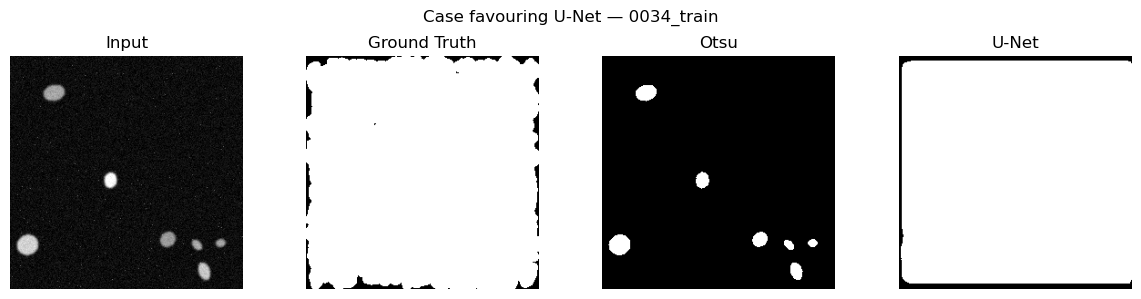

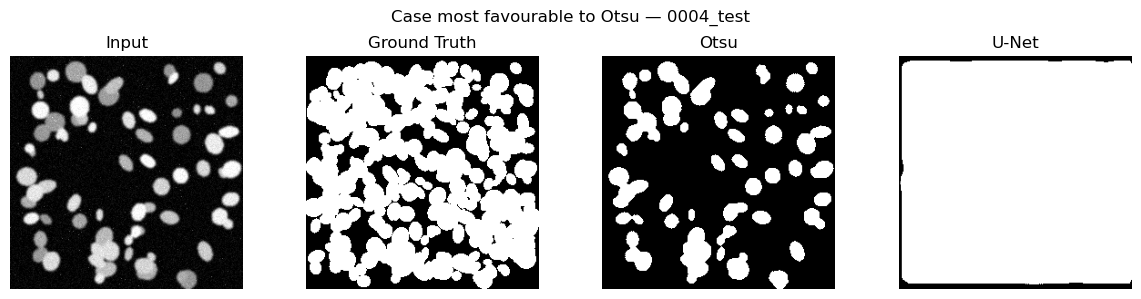

In [83]:
def show_method_comparison(image_id, title):
    record = next(
        r for r in val_records
        if r["image_id"] == image_id
    )

    image = load_grayscale_image(record["image_path"])
    gt = load_grayscale_image(record["mask_path"]) > 0.5

    otsu_pred, threshold = otsu_segment(image)
    unet_pred, probability = predict_mask(model, image)

    plt.figure(figsize=(12, 3))

    plt.subplot(1, 4, 1)
    plt.imshow(image, cmap="gray")
    plt.title("Input")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(gt, cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(otsu_pred, cmap="gray")
    plt.title("Otsu")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(unet_pred, cmap="gray")
    plt.title("U-Net")
    plt.axis("off")

    plt.suptitle(title + " — " + image_id)
    plt.tight_layout()
    plt.show()


show_method_comparison(
    best_for_unet["image_id"],
    "Case favouring U-Net"
)

show_method_comparison(
    best_for_otsu["image_id"],
    "Case most favourable to Otsu"
)

# Task 4 — Hybrid Pipeline

## 30. Final Pipeline

For each unseen image:

**Image → U-Net mask → regionprops → numerical summary → LLM JSON → validated JSON → narrative**

The JSON is the source of truth.

Measured values (`image_id`, `n_objects`, and `mean_area`) are reinserted from Python after the LLM call so the language model cannot silently change them.

In [85]:
def clean_classification(value, allowed):
    if not isinstance(value, str):
        return "uncertain"

    value = value.strip().lower()

    if value in allowed:
        return value

    return "uncertain"


def deterministic_density(foreground_fraction):
    # Fallback only if the LLM call fails.
    if foreground_fraction < 0.08:
        return "low"

    if foreground_fraction < 0.20:
        return "moderate"

    return "high"


def hybrid_record_from_image(model, record):
    image = load_grayscale_image(record["image_path"])

    prediction, probability = predict_mask(
        model,
        image
    )

    feature_table, labelled_prediction = extract_region_features(
        image,
        prediction
    )

    summary = summarise_feature_table(
        feature_table,
        image.shape
    )

    measured_n_objects = int(summary["n_objects"])
    measured_mean_area = round(float(summary["mean_area"]), 3)

    prompt = f"""
You are completing a structured record from measured biomedical image-analysis values.

You cannot see the image.
Do not diagnose disease.
Do not invent visual findings.

Measured values:
image_id = {record["image_id"]}
n_objects = {measured_n_objects}
mean_area = {measured_mean_area}
foreground_fraction = {summary["foreground_fraction"]:.6f}
mean_eccentricity = {summary["mean_eccentricity"]:.6f}
mean_solidity = {summary["mean_solidity"]:.6f}
mean_intensity = {summary["mean_intensity"]:.6f}

Return JSON only with exactly:
{{
  "image_id": "{record["image_id"]}",
  "n_objects": {measured_n_objects},
  "mean_area": {measured_mean_area},
  "density_class": "low, moderate, high, or uncertain",
  "quality_flag": "ok, review, or uncertain"
}}

Do not change image_id, n_objects, or mean_area.
"""

    llm_text = call_ollama(
        prompt=prompt,
        model=TEXT_MODEL,
        temperature=0.1,
        json_mode=True
    )

    parsed = safe_json(llm_text)

    if parsed is None:
        parsed = {
            "image_id": record["image_id"],
            "n_objects": measured_n_objects,
            "mean_area": measured_mean_area,
            "density_class": deterministic_density(
                summary["foreground_fraction"]
            ),
            "quality_flag": "uncertain"
        }

    parsed["image_id"] = record["image_id"]
    parsed["n_objects"] = measured_n_objects
    parsed["mean_area"] = measured_mean_area

    parsed["density_class"] = clean_classification(
        parsed.get("density_class"),
        {"low", "moderate", "high", "uncertain"}
    )

    parsed["quality_flag"] = clean_classification(
        parsed.get("quality_flag"),
        {"ok", "review", "uncertain"}
    )

    return parsed, feature_table, prediction, summary

## 31. Narrative Generation from Validated JSON

The narrative model receives only the validated JSON and is forbidden from adding new clinical facts.

In [87]:
def narrative_from_json(record_json):
    prompt = f"""
Write one short paragraph describing this biomedical image-analysis record.

Rules:
- Use only the information in the JSON.
- Do not add visual details that are not present.
- Do not diagnose disease.
- Do not make clinical recommendations.
- If a field says uncertain, preserve that uncertainty.
- Mention that the values come from an automated image-analysis pipeline.

JSON:
{json.dumps(record_json, indent=2)}
"""

    narrative = call_ollama(
        prompt=prompt,
        model=TEXT_MODEL,
        temperature=0.2,
        json_mode=False
    )

    if narrative.strip() == "":
        narrative = (
            f'Automated analysis for {record_json["image_id"]} detected '
            f'{record_json["n_objects"]} objects with a mean area of '
            f'{record_json["mean_area"]} pixels. The density classification '
            f'is {record_json["density_class"]}, while the quality flag is '
            f'{record_json["quality_flag"]}.'
        )

    return narrative

## 32. Run the Hybrid Pipeline on All Unseen Test Images

If separate unlabeled images exist, they are used. Otherwise the held-out test split is used.

In [96]:
if len(unlabelled_records) > 0:
    hybrid_test_records = unlabelled_records
    print("Using separate unlabeled images as the hybrid test set.")
else:
    hybrid_test_records = test_records
    print("Using the held-out labelled test split as the hybrid test set.")


hybrid_json_records = []
hybrid_rows = []

for number, record in enumerate(hybrid_test_records):
    print(
        f"Processing {number + 1}/{len(hybrid_test_records)}:",
        record["image_id"]
    )

    structured_json, feature_table, prediction, summary = hybrid_record_from_image(
        model,
        record
    )

    narrative = narrative_from_json(
        structured_json
    )

    hybrid_json_records.append(structured_json)

    row = structured_json.copy()
    row["narrative"] = narrative

    hybrid_rows.append(row)


hybrid_dataframe = pd.DataFrame(hybrid_rows)

display(hybrid_dataframe.head())

Using separate unlabeled images as the hybrid test set.
Processing 1/4: 0012_test_corrupted
Ollama call failed: 404 Client Error: Not Found for url: http://localhost:11434/api/generate
Ollama call failed: 404 Client Error: Not Found for url: http://localhost:11434/api/generate
Processing 2/4: 0013_test_corrupted
Ollama call failed: 404 Client Error: Not Found for url: http://localhost:11434/api/generate
Ollama call failed: 404 Client Error: Not Found for url: http://localhost:11434/api/generate
Processing 3/4: 0014_test_corrupted
Ollama call failed: 404 Client Error: Not Found for url: http://localhost:11434/api/generate
Ollama call failed: 404 Client Error: Not Found for url: http://localhost:11434/api/generate
Processing 4/4: 0015_test_corrupted
Ollama call failed: 404 Client Error: Not Found for url: http://localhost:11434/api/generate
Ollama call failed: 404 Client Error: Not Found for url: http://localhost:11434/api/generate


,image_id,n_objects,mean_area,density_class,quality_flag,narrative
0,0012_test_corrupted,2,30966.0,high,uncertain,Automated analysis for 0012_test_corrupted det...
1,0013_test_corrupted,1,60701.0,high,uncertain,Automated analysis for 0013_test_corrupted det...
2,0014_test_corrupted,2,30935.5,high,uncertain,Automated analysis for 0014_test_corrupted det...
3,0015_test_corrupted,1,60702.0,high,uncertain,Automated analysis for 0015_test_corrupted det...


## 33. Save the Aggregated CSV and JSON Records

In [ ]:
csv_path = OUTPUT_DIR / "hybrid_test_records.csv"
json_path = OUTPUT_DIR / "hybrid_test_records.json"

hybrid_dataframe.to_csv(
    csv_path,
    index=False
)

with open(json_path, "w", encoding="utf-8") as f:
    json.dump(
        hybrid_json_records,
        f,
        indent=2
    )

print("CSV saved to:", csv_path)
print("JSON saved to:", json_path)

## 34. Example Final JSON and Narrative

Useful for the report.

In [100]:
if len(hybrid_rows) > 0:
    example_row = hybrid_rows[0]

    example_json = {
        key: example_row[key]
        for key in [
            "image_id",
            "n_objects",
            "mean_area",
            "density_class",
            "quality_flag"
        ]
    }

    print("EXAMPLE STRUCTURED JSON")
    print(json.dumps(example_json, indent=2))

    print("\nEXAMPLE NARRATIVE")
    print(example_row["narrative"])

EXAMPLE STRUCTURED JSON
{
  "image_id": "0012_test_corrupted",
  "n_objects": 2,
  "mean_area": 30966.0,
  "density_class": "high",
  "quality_flag": "uncertain"
}

EXAMPLE NARRATIVE
Automated analysis for 0012_test_corrupted detected 2 objects with a mean area of 30966.0 pixels. The density classification is high, while the quality flag is uncertain.


# Optional Extra Credit — Robustness

## 35. Blur One Image and Trace the Effect

This tests how a heavy blur propagates through the U-Net mask and region measurements.

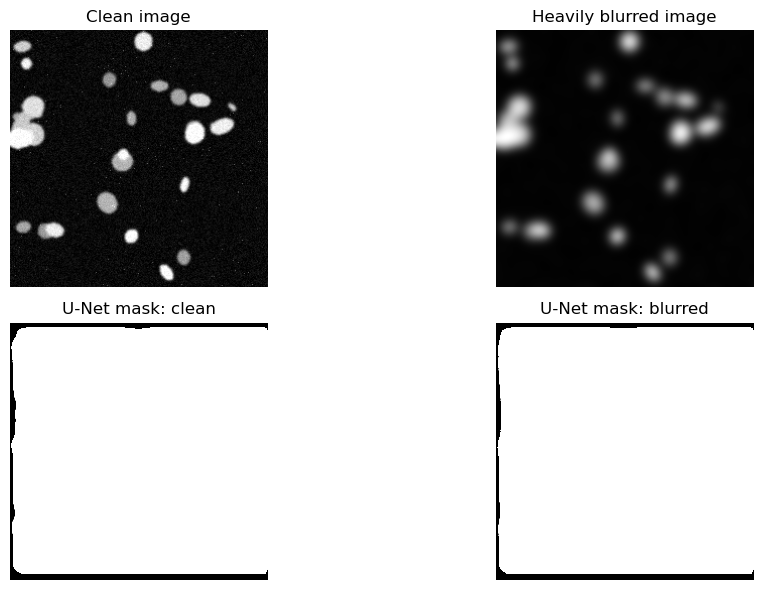

,Version,n_objects,mean_area,median_area,total_object_area,foreground_fraction,mean_eccentricity,mean_solidity,mean_intensity
0,Clean,1,61794.0,61794.0,61794.0,0.942902,0.246247,0.992531,0.035804
1,Blurred,1,61833.0,61833.0,61833.0,0.943497,0.247191,0.993732,0.035502


In [102]:
robust_record = val_records[0]

clean_image = load_grayscale_image(
    robust_record["image_path"]
)

blurred_image = gaussian(
    clean_image,
    sigma=5.0,
    preserve_range=True
)

clean_prediction, clean_probability = predict_mask(
    model,
    clean_image
)

blurred_prediction, blurred_probability = predict_mask(
    model,
    blurred_image
)

clean_features, _ = extract_region_features(
    clean_image,
    clean_prediction
)

blurred_features, _ = extract_region_features(
    blurred_image,
    blurred_prediction
)

clean_summary = summarise_feature_table(
    clean_features,
    clean_image.shape
)

blurred_summary = summarise_feature_table(
    blurred_features,
    blurred_image.shape
)

plt.figure(figsize=(12, 6))

plt.subplot(2, 2, 1)
plt.imshow(clean_image, cmap="gray")
plt.title("Clean image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(blurred_image, cmap="gray")
plt.title("Heavily blurred image")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(clean_prediction, cmap="gray")
plt.title("U-Net mask: clean")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(blurred_prediction, cmap="gray")
plt.title("U-Net mask: blurred")
plt.axis("off")

plt.tight_layout()
plt.show()

robustness_table = pd.DataFrame([
    {"Version": "Clean", **clean_summary},
    {"Version": "Blurred", **blurred_summary}
])

display(robustness_table)

# 36. Save the Prompts Used in the Assignment

This makes it easy to copy the exact prompts into the report.

In [123]:
prompt_file = OUTPUT_DIR / "assignment_prompts.txt"

with open(prompt_file, "w", encoding="utf-8") as f:
    f.write("NAIVE VLM PROMPT\n")
    f.write("=" * 70 + "\n")
    f.write(NAIVE_VLM_PROMPT.strip())

    f.write("\n\nOPTIMISED DIRECT VLM PROMPT\n")
    f.write("=" * 70 + "\n")
    f.write(OPTIMISED_VLM_PROMPT.strip())

    f.write("\n\nNUMBERS-FIRST PROMPT TEMPLATE\n")
    f.write("=" * 70 + "\n")
    f.write(NUMBERS_FIRST_PROMPT_TEMPLATE.strip())

print("Prompts saved")

Prompts saved


# 37. Report Questions — Results Helper

## Q1. Direct VLM or numbers-first?
Discuss usefulness versus trustworthiness. The VLM may be richer, while the numbers-first path is easier to audit because it is grounded in measured features.

## Q2. Did U-Net improve on Otsu?
Use `metrics_table`, `per_image_comparison`, and the comparison figures.

## Q3. What do Dice and IoU mean?
Use `unet_val_dice` and `unet_val_iou`. Discuss boundary errors, false positives, false negatives, merged objects, or missed small nuclei where visible.

## Q4. Where can the LLM hallucinate?
Potential points are the direct VLM, feature interpretation, and final narrative. Explain how `"uncertain"`, constrained JSON, numerical grounding, and validated source-of-truth JSON reduce the risk.

## Q5. Would you trust the system clinically?
The expected critical position is that a small coursework dataset and non-clinically validated models are not enough for clinical deployment. A major improvement would be external validation using a larger expert-annotated dataset representative of the intended clinical setting.

# 38. Final Output Checklist

After running the notebook, the `outputs/` folder should contain:

- `small_unet_bce_dice.pth`
- `representative_otsu_region_features.csv`
- `per_image_otsu_vs_unet.csv`
- `validation_metrics.csv`
- `hybrid_test_records.csv`
- `hybrid_test_records.json`
- `assignment_prompts.txt`

For the final four-page report, choose only the strongest figures and tables.